### Question 1

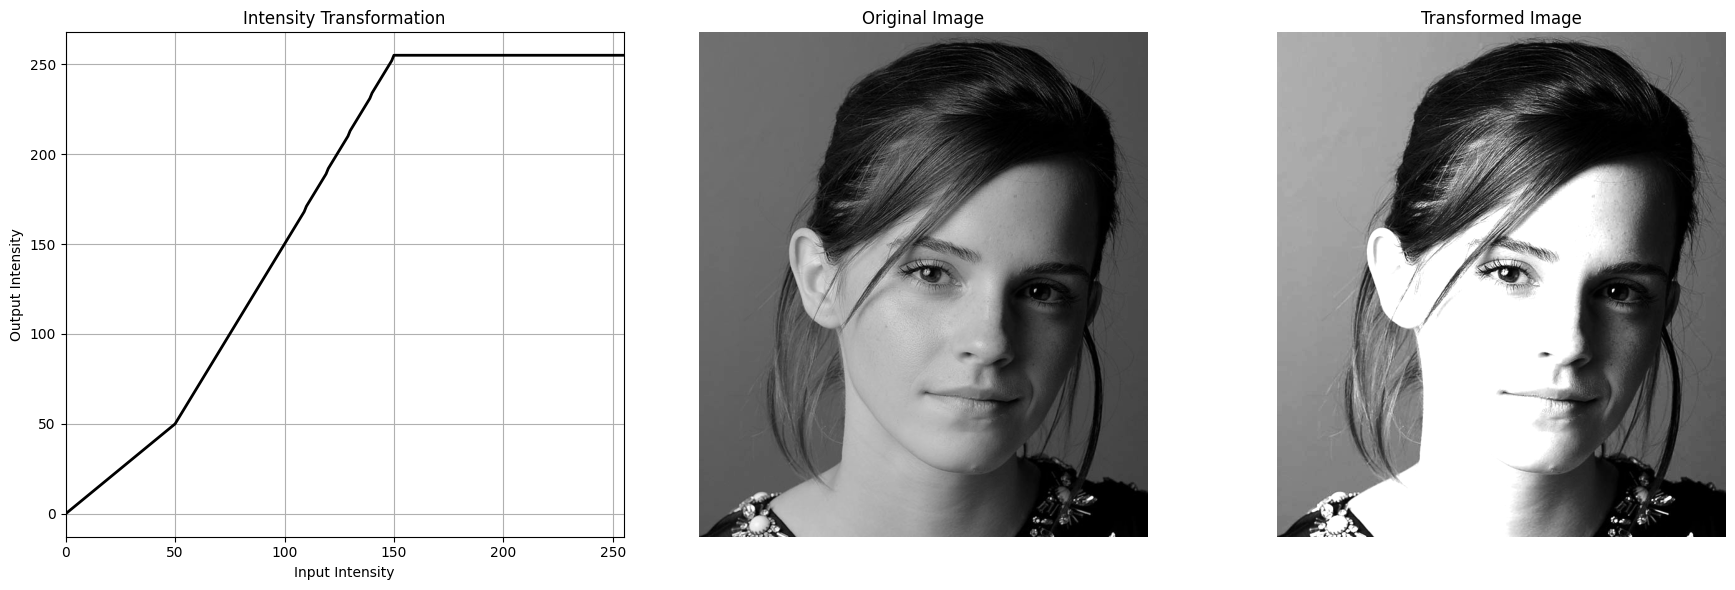

In [104]:
import cv2 
import matplotlib.pyplot as plt
import numpy as np

def intensity_transform(im, breakpoints):
    # Applies a piecewise linear intensity transformation using a lookup table (LUT)

    points = np.array(breakpoints)
    x_in, y_out = points[:, 0], points[:, 1]

    lut = np.interp(np.arange(256), x_in, y_out).astype(np.uint8)

    transformed_im = cv2.LUT(im, lut)
    return transformed_im, lut


breakpoints_1= [[0, 0], [50, 50], [100, 150], [150, 255], [255, 255]]

im = cv2.imread("images/q1.jpeg", cv2.IMREAD_GRAYSCALE)

transformed_im_1, lut_1 = intensity_transform(im, breakpoints_1)

# Plotting transformation curve and side-by-side images 
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].plot(np.arange(256), lut_1, linestyle='solid', linewidth= 2, color= 'black')
ax[0].set_title('Intensity Transformation') 
ax[0].set_xlabel('Input Intensity')
ax[0].set_ylabel('Output Intensity')
ax[0].set_xlim([0, 255])
ax[0].grid(True)

ax[1].imshow(im, cmap="gray")
ax[1].set_title('Original Image')
ax[1].axis('off')

ax[2].imshow(transformed_im_1, cmap="gray")
ax[2].set_title('Transformed Image')
ax[2].axis('off')

plt.tight_layout()
plt.show()

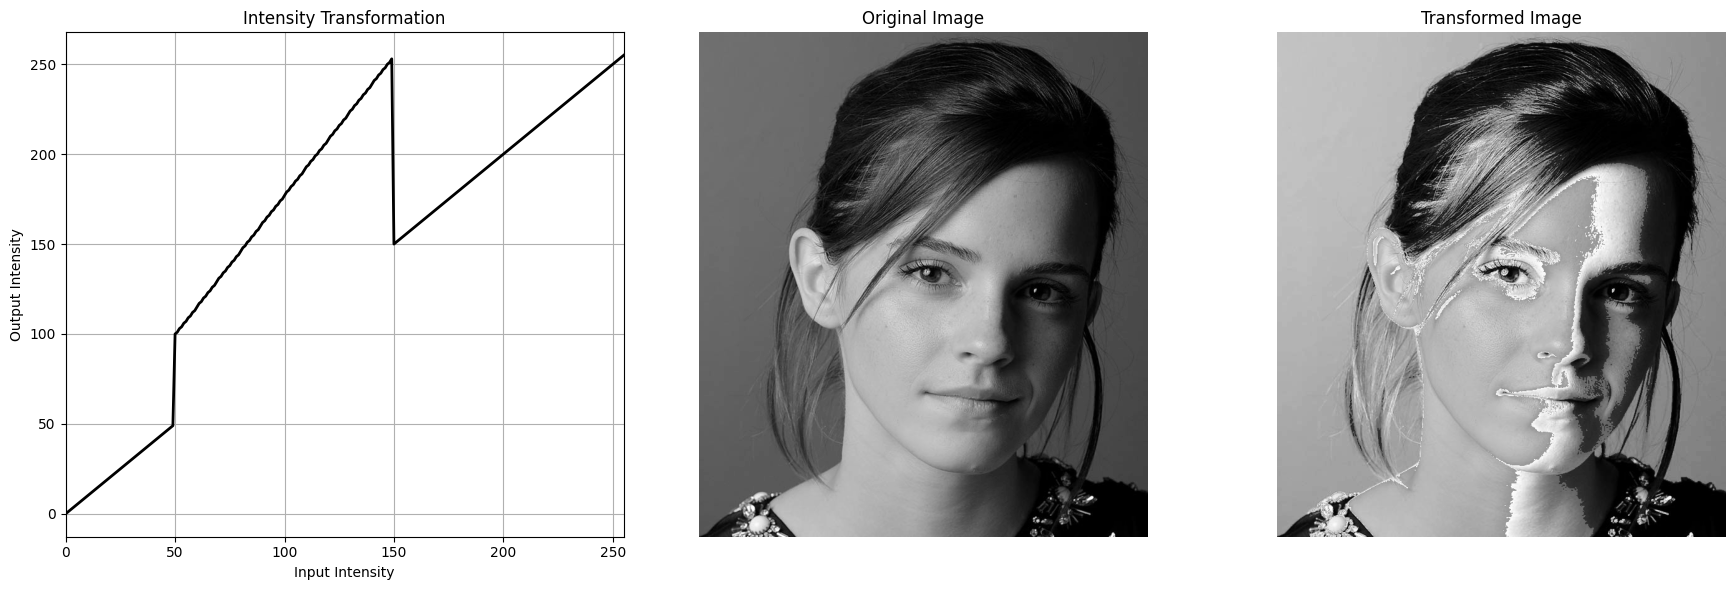

In [105]:
breakpoints_2= [[0, 0], [50, 50], [50, 100], [150, 255], [150, 150], [255, 255]]

transformed_im_2, lut_2 = intensity_transform(im, breakpoints_2)

# Plotting transformation curve and side-by-side images 
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].plot(np.arange(256), lut_2, linestyle='solid', linewidth= 2, color= 'black')
ax[0].set_title('Intensity Transformation') 
ax[0].set_xlabel('Input Intensity')
ax[0].set_ylabel('Output Intensity')
ax[0].set_xlim([0, 255])
ax[0].grid(True)

ax[1].imshow(im, cmap="gray")
ax[1].set_title('Original Image')
ax[1].axis('off')

ax[2].imshow(transformed_im_2, cmap="gray")
ax[2].set_title('Transformed Image')
ax[2].axis('off')

plt.tight_layout()
plt.show()

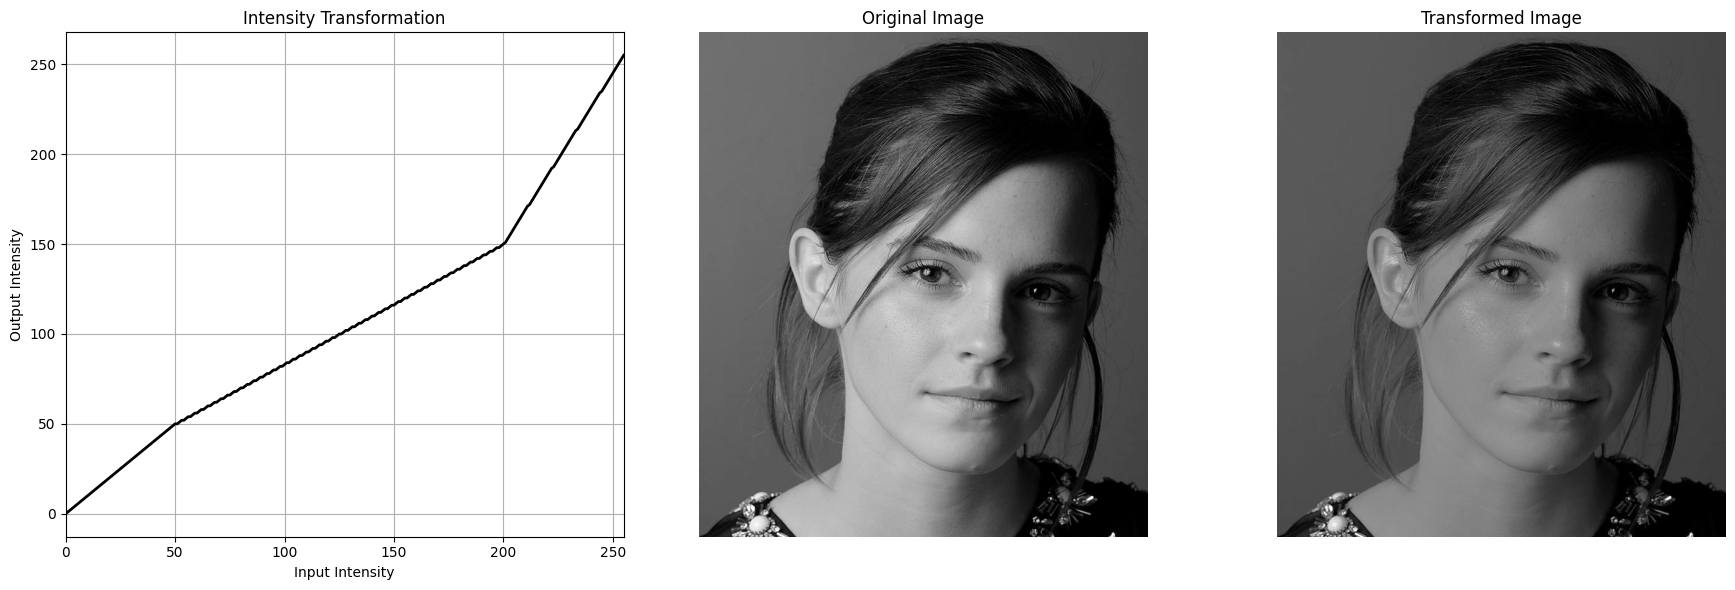

In [106]:
breakpoints_3= [[0, 0], [50, 50], [200, 150], [255, 255]]

transformed_im_3, lut_3 = intensity_transform(im, breakpoints_3)

# Plotting transformation curve and side-by-side images 
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].plot(np.arange(256), lut_3, linestyle='solid', linewidth= 2, color= 'black')
ax[0].set_title('Intensity Transformation') 
ax[0].set_xlabel('Input Intensity')
ax[0].set_ylabel('Output Intensity')
ax[0].set_xlim([0, 255])
ax[0].grid(True)

ax[1].imshow(im, cmap="gray")
ax[1].set_title('Original Image')
ax[1].axis('off')

ax[2].imshow(transformed_im_3, cmap="gray")
ax[2].set_title('Transformed Image')
ax[2].axis('off')

plt.tight_layout()
plt.show()

### Question 2

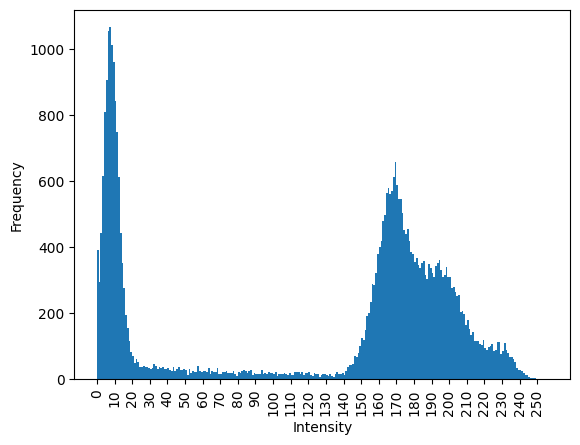

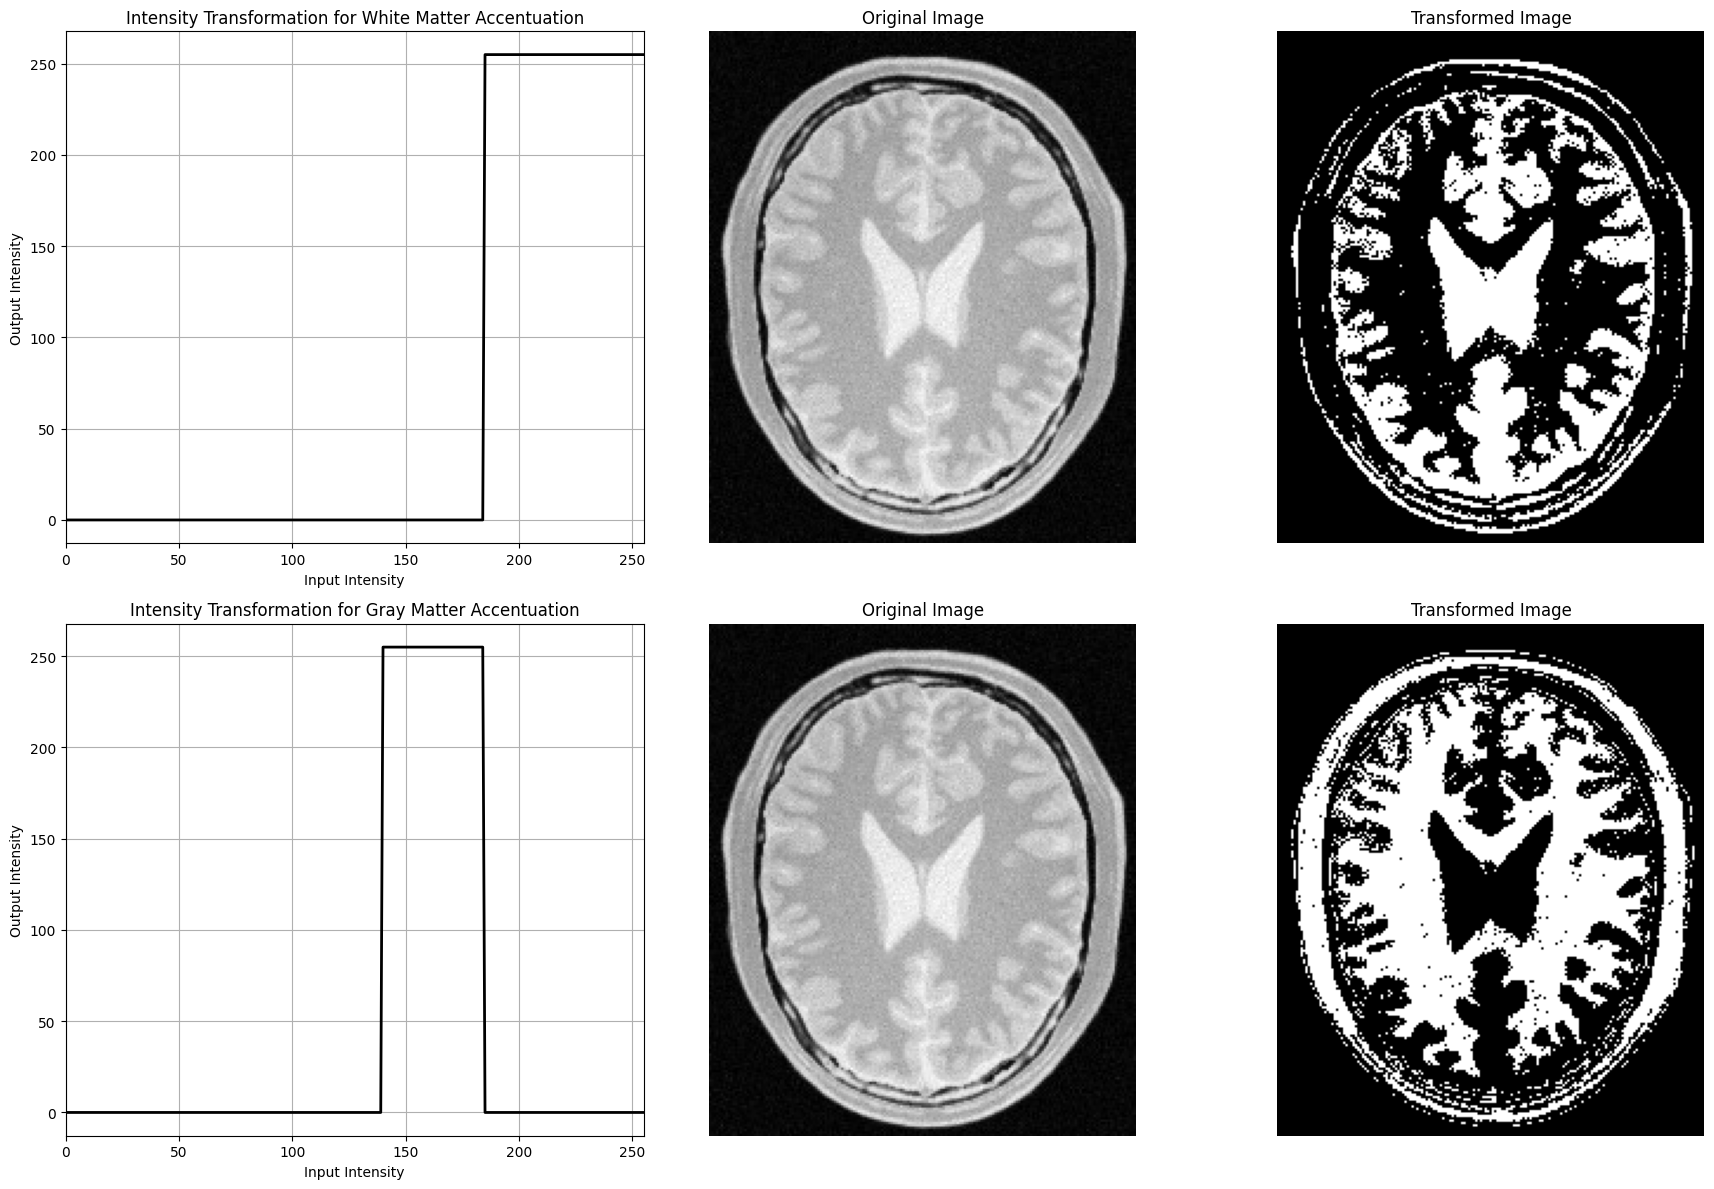

In [107]:
breakpoints_4= [[0, 0], [184, 0], [185, 255],[255, 255]] 
breakpoints_5= [[0, 0], [139, 0], [140, 255],[184, 255], [185, 0], [255, 0]]

im_1 = cv2.imread("images/q2.jpeg", cv2.IMREAD_GRAYSCALE)

transformed_im_4, lut_4 = intensity_transform(im_1, breakpoints_4)
transformed_im_5, lut_5 = intensity_transform(im_1, breakpoints_5)

# plotting histogram of the original image to identify the intensity distribution
plt.hist(im_1.ravel(), bins=256, range=[0,256])
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.xticks(np.arange(0, 256, 10), rotation=90)
plt.show()

# Plotting transformation curve and side-by-side images 
fig, ax = plt.subplots(2, 3, figsize=(18, 12))

ax[0][0].plot(np.arange(256), lut_4, linestyle='solid', linewidth= 2, color= 'black')
ax[0][0].set_title('Intensity Transformation for White Matter Accentuation') 
ax[0][0].set_xlabel('Input Intensity')
ax[0][0].set_ylabel('Output Intensity')
ax[0][0].set_xlim([0, 255])
ax[0][0].grid(True)

ax[0][1].imshow(im_1, cmap="gray")
ax[0][1].set_title('Original Image')
ax[0][1].axis('off')

ax[0][2].imshow(transformed_im_4, cmap="gray")
ax[0][2].set_title('Transformed Image')
ax[0][2].axis('off')

ax[1][0].plot(np.arange(256), lut_5, linestyle='solid', linewidth= 2, color= 'black')
ax[1][0].set_title('Intensity Transformation for Gray Matter Accentuation') 
ax[1][0].set_xlabel('Input Intensity')
ax[1][0].set_ylabel('Output Intensity')
ax[1][0].set_xlim([0, 255])
ax[1][0].grid(True)

ax[1][1].imshow(im_1, cmap="gray")
ax[1][1].set_title('Original Image')
ax[1][1].axis('off')

ax[1][2].imshow(transformed_im_5, cmap="gray")
ax[1][2].set_title('Transformed Image')
ax[1][2].axis('off')

plt.tight_layout()
plt.show()

select the range from 140 to 185 as gray matter range and the range from 185 to 255 as white matter range.

### Question 3

Applied Gamma value: 0.7


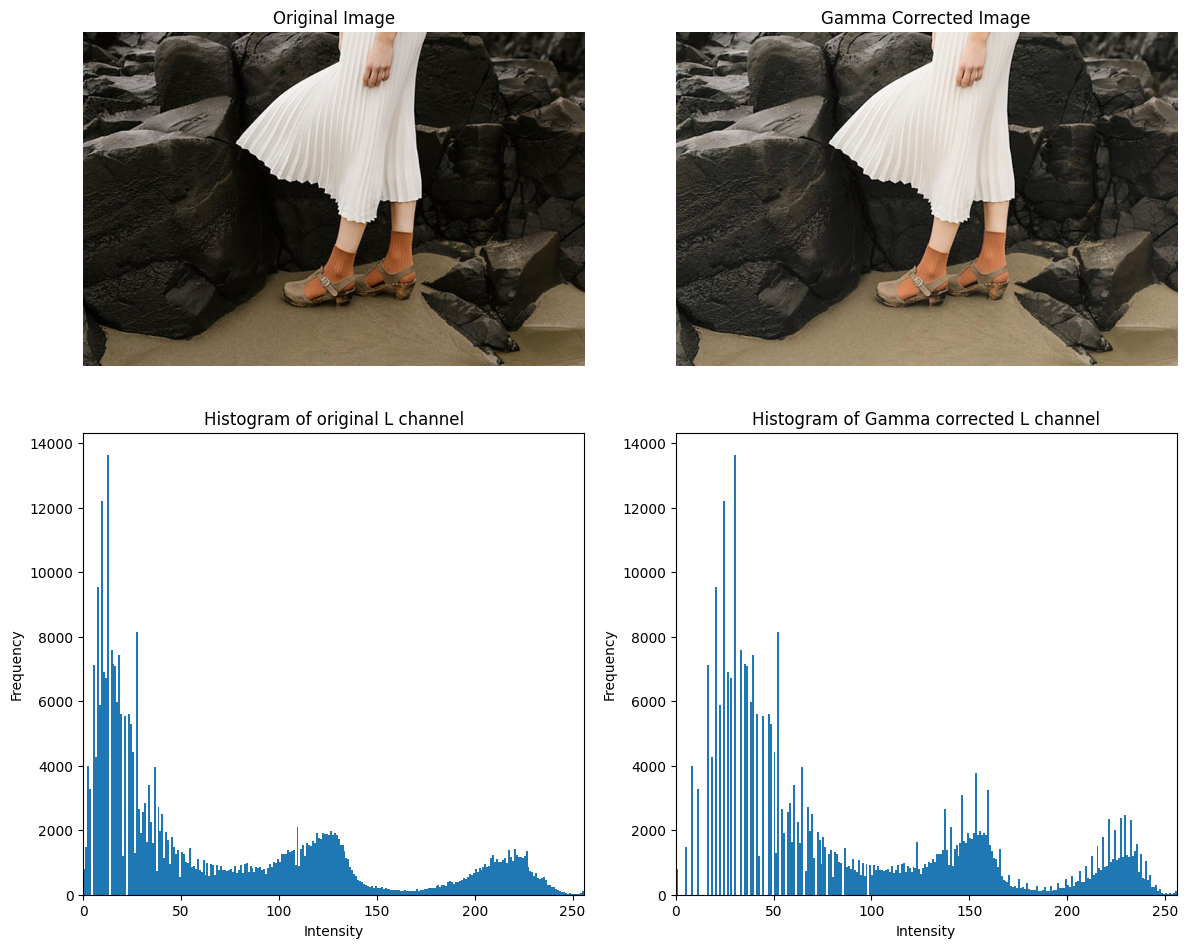

In [123]:
im_bgr = cv2.imread("images/WhatsApp Image 2026-09-09 at 20.02.44 (1).jpeg")

# separating the L*a*b* channels
L, a, b = cv2.split(cv2.cvtColor(im_bgr, cv2.COLOR_BGR2LAB))

# Applying Gamma correction to the L channel
gamma = 0.7
print(f"Applied Gamma value: {gamma}")

lut_gamma = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)]).astype(np.uint8)
L_corrected = cv2.LUT(L, lut_gamma)

# merge corrected L channel with original a and b channels
im_lab_corrected = cv2.merge([L_corrected, a, b])

fig, ax = plt.subplots(2, 2, figsize= (12,10))

# Plotting the original image
ax[0][0].imshow(cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB))
ax[0][0].set_title('Original Image')
ax[0][0].axis('off')

# Plotting Gamma corrected image
ax[0][1].imshow(cv2.cvtColor(im_lab_corrected, cv2.COLOR_LAB2RGB))
ax[0][1].set_title('Gamma Corrected Image')
ax[0][1].axis('off')

# plotting the histogram of original L channel
ax[1][0].hist(L.ravel(), bins= 256, range= [0, 256])
ax[1][0].set_title('Histogram of original L channel')
ax[1][0].set_xlabel('Intensity')
ax[1][0].set_ylabel('Frequency')
ax[1][0].set_xlim([0, 256])

# plotting the histogram of Gamma corrected L channel
ax[1][1].hist(L_corrected.ravel(), bins= 256, range= [0, 256])
ax[1][1].set_title('Histogram of Gamma corrected L channel')
ax[1][1].set_xlabel('Intensity')
ax[1][1].set_ylabel('Frequency')
ax[1][1].set_xlim([0, 256])

plt.tight_layout()
plt.show()

### Question 4

In [124]:
im_2 = cv2.imread("images/WhatsApp Image 2026-09-09 at 20.02.441.jpeg")

# converting the image to HSV color space
im_hsv = cv2.cvtColor(im_2, cv2.COLOR_BGR2HSV)

# separate into planes
hue_plane = im_hsv[:, :, 0]
saturation_plane = im_hsv[:, :, 1]
value_plane = im_hsv[:, :, 2]

In [145]:
# Apply the aforementioned intensity transformation to the saturation plane

a_val = 0.95
sigma = 70.0

x = np.arange(256, dtype=np.float32)
boost = a_val * 128.0 * np.exp(-((x - 128.0) ** 2) / (2.0 * (sigma**2))) 
fx = np.minimum(x + boost, 255.0).astype(np.uint8)

corrected_saturation_plane = cv2.LUT(saturation_plane, fx)

print(f"Applied a value: {a_val}")

Applied a value: 0.95


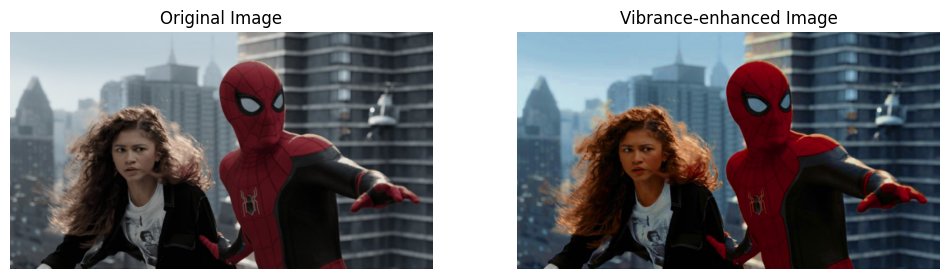

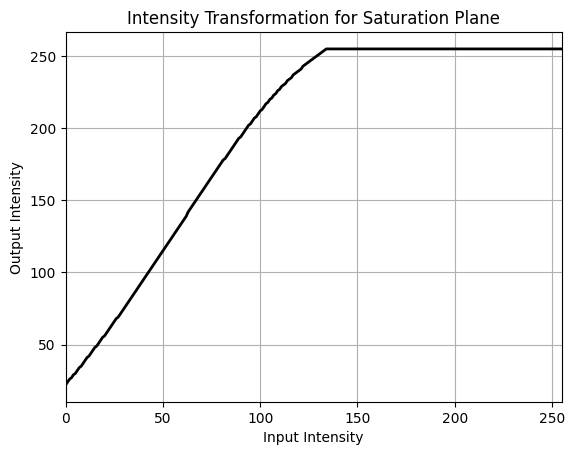

In [146]:
# recombining three planes back to get vibrance-enhanced image
im_hsv_corrected = cv2.merge([hue_plane, corrected_saturation_plane, value_plane])

# showing all plots
fig, ax = plt.subplots(1,2, figsize= (12, 6))

ax[0].imshow(cv2.cvtColor(im_2, cv2.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(cv2.cvtColor(im_hsv_corrected, cv2.COLOR_HSV2RGB))
ax[1].set_title('Vibrance-enhanced Image')
ax[1].axis('off')
plt.show()


plt.plot(np.arange(256), fx, linestyle='solid', linewidth= 2, color= 'black')
plt.title('Intensity Transformation for Saturation Plane')
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.xlim([0, 255])
plt.grid(True)

plt.show()


### Question 5

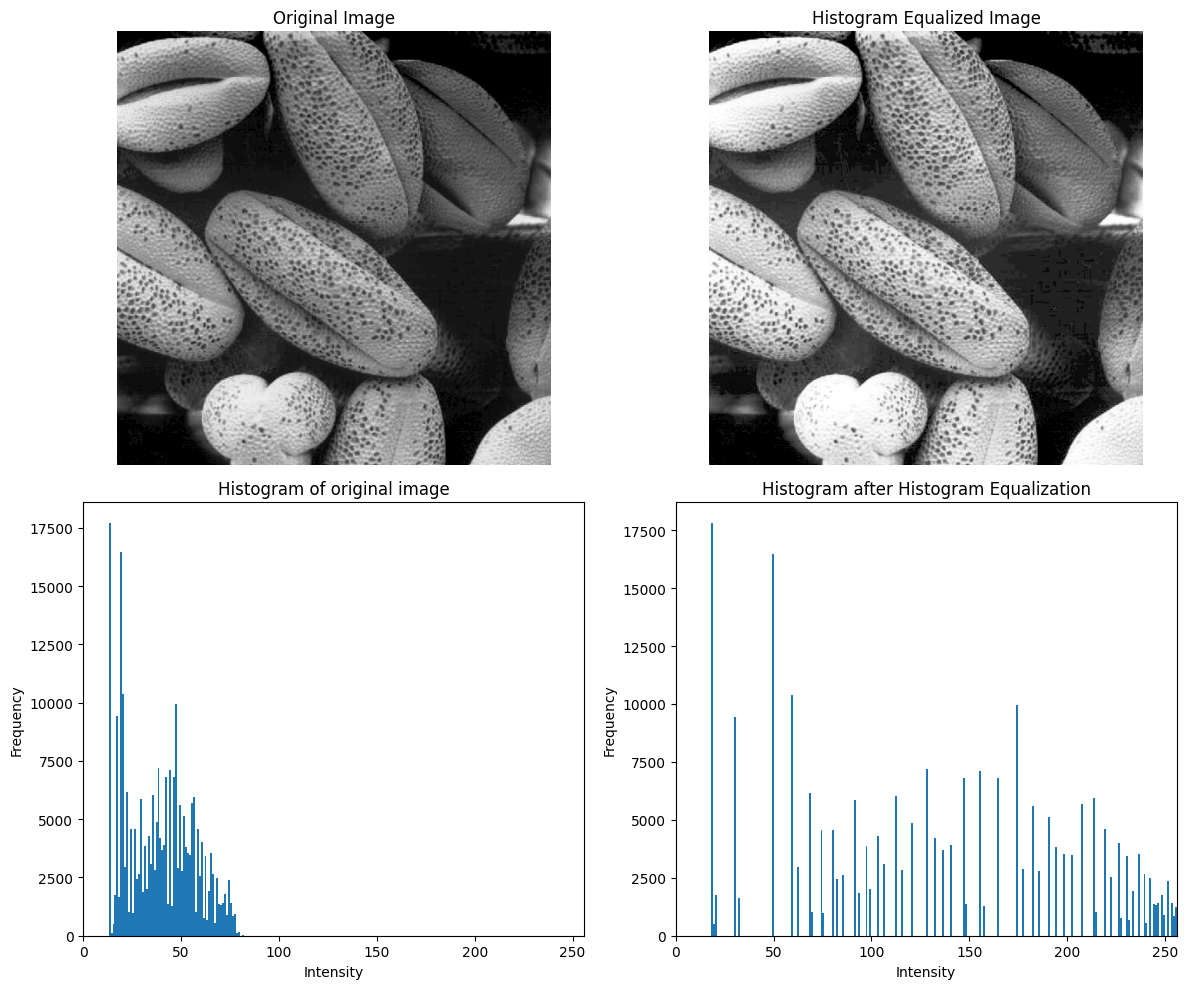

In [160]:
def custom_histogram_equalization(im_gray):
    # Equalize the histogram of grayscale image

    # Compute histogram
    hist, bin_edges = np.histogram(im_gray.flatten(), bins=256, range=(0, 256))

    # Compute PMF and CDF 
    pmf = hist / im_gray.size
    cdf = np.cumsum(pmf)

    # Map CDF to intensity range
    lookup_table = np.round(cdf * 255).astype(np.uint8)

    # Apply mapping 
    equalized_im = lookup_table[im_gray]
    return equalized_im

im_3 = cv2.imread("images/shells.tif", cv2.IMREAD_GRAYSCALE)

equlaized_im_3 = custom_histogram_equalization(im_3)

fig, ax = plt.subplots(2, 2, figsize= (12,10))

# plotting the original image
ax[0][0].imshow(im_3, cmap='gray')
ax[0][0].set_title('Original Image')
ax[0][0].axis('off')

# Plotting histogram qualized image
ax[0][1].imshow(equlaized_im_3, cmap='gray')
ax[0][1].set_title('Histogram Equalized Image')
ax[0][1].axis('off')

# plotting the Histogram of original image
ax[1][0].hist(im_3.flatten(), bins= 256, range= [0, 256])
ax[1][0].set_title('Histogram of original image')
ax[1][0].set_xlabel('Intensity')
ax[1][0].set_ylabel('Frequency')
ax[1][0].set_xlim([0, 256])

# plotting the Histogram after Histogram Equalization
ax[1][1].hist(equlaized_im_3.flatten(), bins= 256, range= [0, 256])
ax[1][1].set_title('Histogram after Histogram Equalization')
ax[1][1].set_xlabel('Intensity')
ax[1][1].set_ylabel('Frequency')
ax[1][1].set_xlim([0, 256])

plt.tight_layout()
plt.show()
